In [109]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv


In [110]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [111]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv')

# Preview data
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


### Dataset Overview

The dataset includes:
- Product Name
- Price
- Rating
- Review
- Summary
- Sentiment (This is the target variable)

We will focus on the **Summary column** for sentiment prediction.

In [112]:
# Check sentiment distribution
df['Sentiment'].value_counts()

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64

In [113]:
# Check shape
df.shape

(205052, 6)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [115]:
# Check missing values
df.isnull().sum()

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

### Handling Missing Values

From exploration:

- `Review` has 24,664 missing values
- `Summary` has 11 missing values

Since sentiment is derived mainly from text (especially *Summary*), we need to handle missing values.

### Strategy:
- Drop rows where `Summary` is missing (very small loss)
- Replace missing `Review` values with empty strings (since it's optional for this project)

In [116]:
# Drop rows with missing Summary (only 11 rows so its safe to remove)
df = df.dropna(subset=['Summary'])

In [117]:
# Replace missing reviews with missing
df['Review'] = df['Review'].fillna("missing")

In [118]:
df.isnull().sum()

product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64

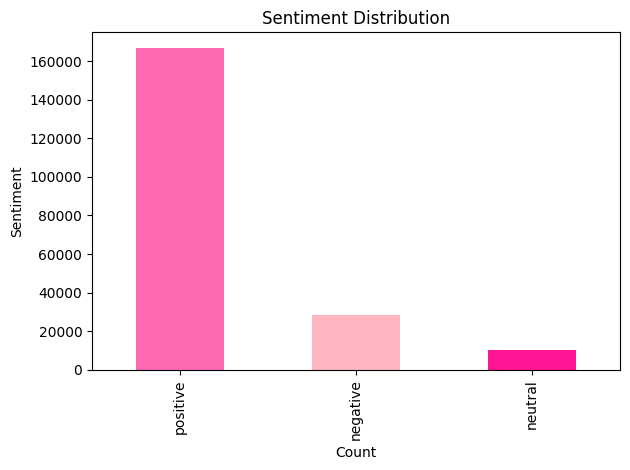

In [119]:
# Sentiment distribution
df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["#FF69B4","#FFB6C1","#FF1493"],
    title="Sentiment Distribution"
    )
plt.ylabel("Sentiment")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

###  Text preprocessing

We combined the Summary and Review columns into a single text feature to capture both short and detailed customer opinions.

We then applied text preprocessing, including:
- Lowercasing
- Removing special characters
- Tokenization
- Stopword removal
- Lemmatization

 Then, grouped cleaned text by sentiment to analyze commonly used words in each category.

In [120]:
import re
from nltk.tokenize import word_tokenize

# Combining text columns first
df['text'] = df['Summary'] + " " + df['Review']

# Preprocessing function
def preprocess(text):
    text = str(text).lower()  # ensure it's string
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    tokens = word_tokenize(text)
    
    tokens = [
        lemmatizer.lemmatize(t) 
        for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    
    return ' '.join(tokens)

# Apply preprocessing
df["cleaned_text"] = df['text'].apply(preprocess)

# Generate word strings for each sentiment
pos_words = ' '.join(df[df['Sentiment'] == 'positive']['cleaned_text'])
neg_words = ' '.join(df[df['Sentiment'] == 'negative']['cleaned_text'])
neu_words = ' '.join(df[df['Sentiment'] == 'neutral']['cleaned_text'])

print(f"Positive: {pos_words[:500]}...\n")
print(f"Negative: {neg_words[:500]}...\n")
print(f"Neutral: {neu_words[:500]}...")

Positive: great cooler excellent air flow price amazing unbelievablejust love super best budget fit cooler nice cooling awesome quality good power air decent fair cooler really fantastic provides good air flow highly recommended awesome good product highly recommended nice nice good worth money beautiful product good material perfectly working great product awesome mind blowing purchase good highly recommended wonderful product must buy brilliant nice air cooler smart cool breeze producer classy product a...

Negative: bad product fan useless product bad cooler unsatisfactory bad quality expected better product small wire moter capacity low fan speed good flow vent hole lower part cooler difficult change water waste money received dalay day cooler reveived switch damaged nice cooler provide cool air year experience worst experience ever quality product wood wool started falling next day two led indicator found working arrival air swinger already giving noise moving never used old coole

In [121]:
# Identify the top 10 most frequent words in each sentiment
pos_split = Counter(pos_words.split()).most_common(10)
neg_split = Counter(neg_words.split()).most_common(10)
neu_split = Counter(neu_words.split()).most_common(10)


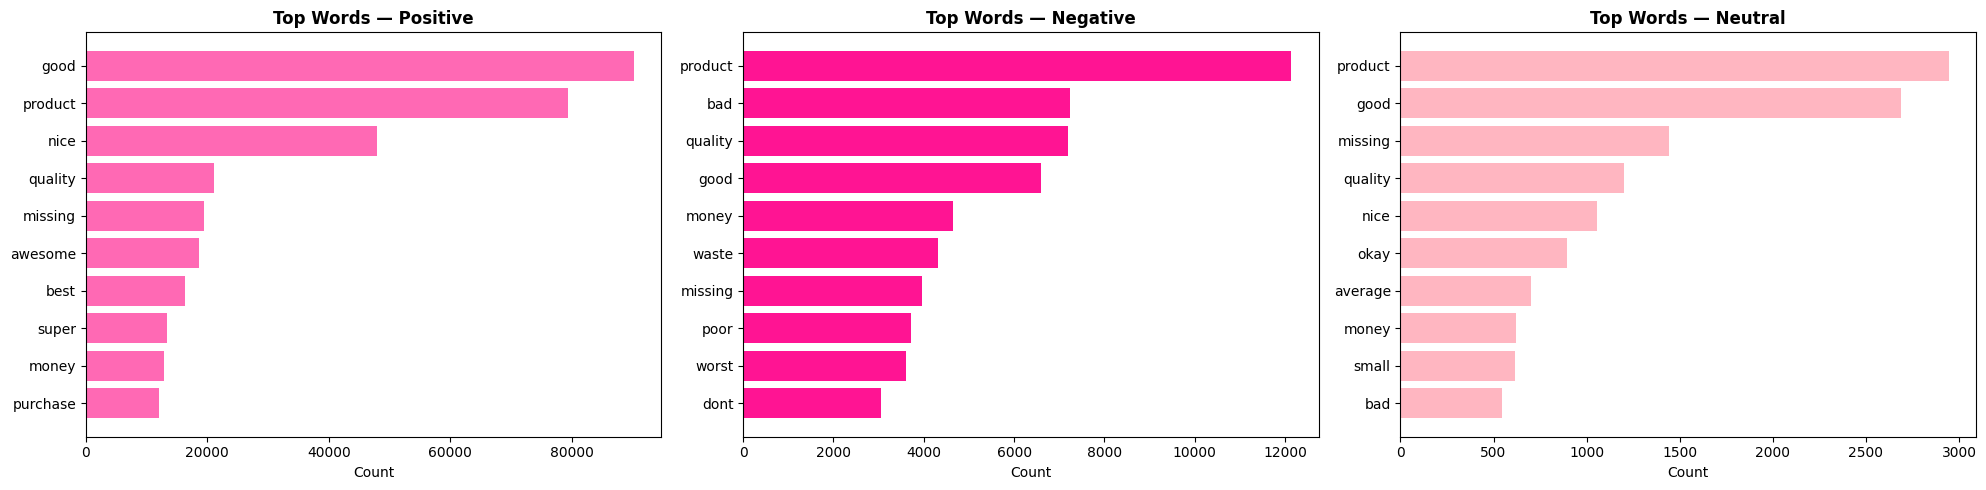

In [122]:
# visualize the top 10 most frequent words per sentiment.
fig, axes = plt.subplots(1,3,figsize=(20,5))

data = [pos_split, neg_split, neu_split]
color = ["#FF69B4", "#FF1493", "#FFB6C1"]
labels = ["Positive", "Negative", "Neutral"]

for ax, dt, clr, lbl in zip(axes, data, color, labels):
  w, c = zip(*dt)
  ax.barh(list(w)[::-1], list(c)[::-1], color=clr)
  ax.set_xlabel("Count")
  ax.set_title(f'Top Words — {lbl}', fontweight='bold')

plt.tight_layout()
plt.show()


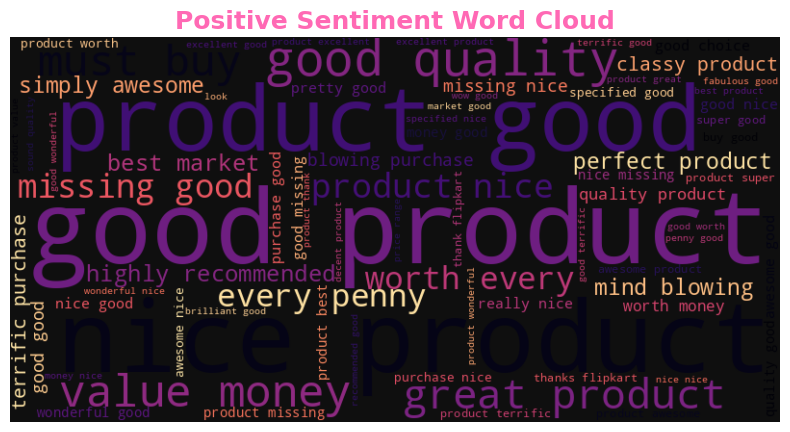

In [123]:
#wordcloud
wc = WordCloud(
    width=800, 
    height=400,
    background_color="#0f0f0f", 
    colormap="magma",          
    max_words=100,
    min_font_size=10,
    contour_width=1,
    contour_color='#FF69B4'     
).generate(pos_words)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear') 
plt.axis("off")
plt.title("Positive Sentiment Word Cloud", fontsize=18, fontweight='bold', color='#FF69B4')
plt.show()


### Feature engineering

We convert text into numerical format using **TF-IDF (Term Frequency-Inverse Document Frequency)**.

In [124]:
# Features and target
X = df["cleaned_text"]
y = df["Sentiment"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF Vectorization
tfidf = TfidfVectorizer( max_features=5000, ngram_range=(1,2), min_df=2)

# Transform text data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Check shapes
print(f'Train Shape: {X_train_tfidf.shape}')
print(f'Test Shape: {X_test_tfidf.shape}') 

Train Shape: (164032, 5000)
Test Shape: (41009, 5000)


### Model Selection

We use **Logistic Regression**, for text classification.

In [125]:
# Initialize model
lr_model = LogisticRegression(max_iter=200)

# Train model
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = lr_model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9264551683776732

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.83      0.84      5646
     neutral       0.68      0.25      0.37      2047
    positive       0.94      0.98      0.96     33316

    accuracy                           0.93     41009
   macro avg       0.82      0.69      0.72     41009
weighted avg       0.92      0.93      0.92     41009



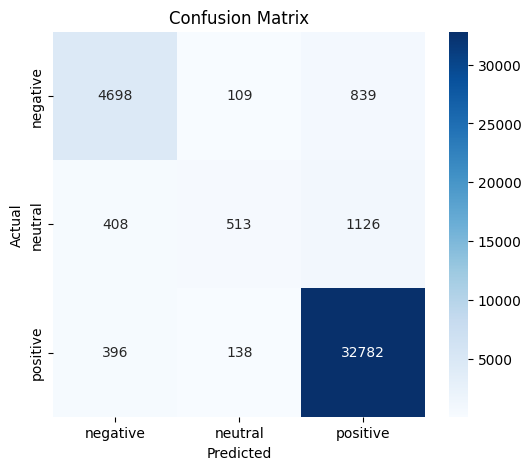

In [126]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [127]:
# Re-run TF-IDF with more room for meaningful phrases
# We increase max_features to 15,000 so the model can 'see' the bigrams better
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2), min_df=2, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression with BALANCED weights
# This is a fix for the Neutral class performance
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_tfidf, y_train)

# Final Evaluation
y_pred = clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.80      0.84      0.82      5646
     neutral       0.28      0.69      0.40      2047
    positive       0.98      0.88      0.93     33316

    accuracy                           0.87     41009
   macro avg       0.69      0.80      0.72     41009
weighted avg       0.92      0.87      0.89     41009



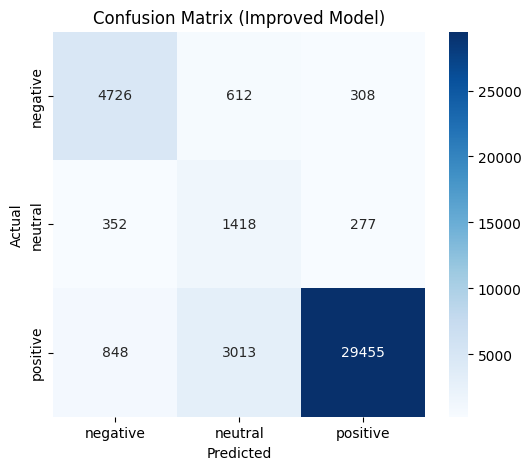

In [128]:
# confusion matrix using the improved model's predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Improved Model)")
plt.show()


In [129]:
# sample sentences to test the model
samples = [
    "The quality is excellent and I highly recommend it!",      #  Positive
    "It works fine, but the delivery took a bit too long.",     #  Neutral
    "I am very unhappy with this purchase, it broke instantly." #  Negative
]

print("--- Sentiment Analysis Test Results ---")

for text in samples:
    vectorized_text = tfidf.transform([text])
    prediction = clf.predict(vectorized_text)[0]
    
    print(f"Text: {text}")
    print(f"Predicted Sentiment: {prediction.upper()}")
    print("-" * 40)


--- Sentiment Analysis Test Results ---
Text: The quality is excellent and I highly recommend it!
Predicted Sentiment: POSITIVE
----------------------------------------
Text: It works fine, but the delivery took a bit too long.
Predicted Sentiment: POSITIVE
----------------------------------------
Text: I am very unhappy with this purchase, it broke instantly.
Predicted Sentiment: NEGATIVE
----------------------------------------


In [130]:
# This shows the words the model thinks are MOST important
feature_names = tfidf.get_feature_names_out()
for i, class_label in enumerate(clf.classes_):
    # Get the coefficients (weights) for this class
    top_indices = clf.coef_[i].argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"Top 10 words for {class_label.upper()}: {top_words}")


Top 10 words for NEGATIVE: ['worst', 'broken', 'disappointed', 'bad', 'damage', 'damaged', 'waste', 'problem', 'poor', 'low']
Top 10 words for NEUTRAL: ['product', 'worst experience', 'average', 'way better', 'best market', 'goodbut', 'okay', 'pretty good', 'terrific', 'perfect product']
Top 10 words for POSITIVE: ['best', 'love', 'thanks', 'amazing', 'nice product', 'loved', 'good product', 'awesome product', 'good quality', 'superb']


In [131]:
# Updated test samples using the words the model actually knows for Neutral
samples = [
    "The quality is excellent and I highly recommend it!",      # Expected: Positive
    "The product is average and okay for the price.",           # Expected: Neutral
    "I am very unhappy with this purchase, it broke instantly." # Expected: Negative
]

print("--- Final Sentiment Analysis Test Results ---")

for text in samples:
    # 1. Transform the text
    vectorized_text = tfidf.transform([text])
    
    # 2. Get the prediction array
    prediction = clf.predict(vectorized_text)
    
    # 3. Access the first element [0] and then make it uppercase
    print(f"Text: {text}")
    print(f"Predicted Sentiment: {prediction[0].upper()}")
    print("-" * 40)


--- Final Sentiment Analysis Test Results ---
Text: The quality is excellent and I highly recommend it!
Predicted Sentiment: POSITIVE
----------------------------------------
Text: The product is average and okay for the price.
Predicted Sentiment: NEUTRAL
----------------------------------------
Text: I am very unhappy with this purchase, it broke instantly.
Predicted Sentiment: NEGATIVE
----------------------------------------
